
# Final Exam - DS 325 Applied Data Science

In this final exercise, you will given the opportunity to choose between two datasets and analyses in order to tell a data story.  

One of the datasets was the first dataset we explored in this course, tracking the COVID pandemic numbers.  This dataset should be used in a time-series analysis in order to produce a forecast.  

The other dataset is a new dataset which will be used in a classification analysis in order to make predictions based on categories of data.  

Each dataset and analysis presents the opportunity for its own unique preparation and analysis.  The details for each project are below, but the ultimate expectations, data products, and analysis will be very similar.  
_________________________________________________________



## Specific items to be sure to include, regardless of which option you chooose

In your discussion you should:
 * describe what models you are exploring, and why they are preferred/appropriate for the analysis you're performing
 * clearly state what data is being used to train the model and what the model is predicting  
 * keep validation and testing accuracy in mind when optimizing, you want your model as generalizeable as possible
 * present the performance of your model on the training and validation/test data sets
 * summarize your performance results into a single table for easy comparison of your difference models'


No matter your model, you should:
 * prepare your training and target data before training (apply sampling, scaling, or any other transformations prior to modelling)
 * demonstrate that you have optimized your model parameter choice
 * include visualizations to help illustrate each model's performance
 * take care in presenting your results.  **All results and discussion should be written in markdown format at the end of your code.  Do not expect me to grade discussion written in the comments**  


You should use some of your time in class today/thursday to ask questions and narrow in on your methodology.  **From the time after receiving the dataset, you are not to speak about the exam or methods with anyone besides me until our final examination period has elapsed.**  

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_fscore_support


from matplotlib.colors import LogNorm
import sklearn.metrics as metrics

import kagglehub
import urllib.request
import tensorflow as tf


from matplotlib.colors import ListedColormap
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier

from sklearn.model_selection import GridSearchCV

np.random.seed(42)

import itertools
from itertools import permutations

#define the default font sizes to make the figures prettier
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [2]:
# From a class workbook

def class_performance(xdata,ydata,model):

# Classifiers with the score method output accuracy by default
  acc = model.score(xdata,ydata)
  predy = model.predict(xdata)
  prec, rec, fscore, supp = precision_recall_fscore_support(ydata, predy, average=None, zero_division=0)
  print("\nmodel accuracy on supplied data:\t", acc)
  # print("Precision:\t", prec.round(3),
  #       "\nRecall:\t\t", rec.round(3),
  #       "\nFscore:\t\t", fscore.round(3),
  #       "\nSupport:\t", supp)
  print("Precision:\t", prec,
        "\nRecall:\t\t", rec,
        "\nFscore:\t\t", fscore,
        "\nSupport:\t", supp)

#Option 1:  A New Dataset - Demographics, Personality, and Drug Use




## General Data description

This dataset contains samples for 1885 respondents and records demographic, personality, and history of drug use information. For each respondent, 12 attributes are measured: **5 Personality measurements** (the so-called BIG 5) which include **NEO-FFI-R** (**neuroticism, extraversion, openness to experience, agreeableness, and conscientiousness**), **impulsivity/risky behavior measurements**:  **BIS-11** (impulsivity) and **ImpSS (sensation seeking)**, along with **other demographic information** (level of education, age, gender, country of residence and ethnicity.) All input attributes were originally categorical and have been transformed and scaled to have a mean value of zero.  

The dataset features may be broadly categorized as being **Demographic**, **Personality**, **Risk-seeking**; more detailed descriptions for each category and feature are available below.

In addition to the above **personality**, **risk-seeking**, and **demographic** information, participants were questioned concerning their **use of 18 legal and illegal drugs (alcohol, amphetamines, amyl nitrite, benzodiazepine, cannabis, chocolate, cocaine, caffeine, crack, ecstasy, heroin, ketamine, legal highs, LSD, methadone, mushrooms, nicotine and volatile substance abuse (inhalents), for a total of 18 possible drug targets**, along with one fictitious drug (**Semeron**) which was introduced to identify over-claimers.

Each drug target can have 1 of 7 responses: "Never Used", "Used over a Decade Ago", "Used in Last Decade", "Used in Last Year", "Used in Last Month", "Used in Last Week", and "Used in Last Day".  These categorical responses will be encoded below as numbers 0-6.

The original dataset acquisition and analysis is described in this 2015 paper:

[Arxiv Link](https://arxiv.org/abs/1506.06297)








## Feature Categories and Descriptions

### Demographic Traits

The following features could all be included in the broader category of  **Demographic data**

**Age**: the age of participant and has one of the values:

Value	Meaning	Cases	Fraction (order increasing age)

* -0.95197 18-24	643	34.11%
* -0.07854  25-34	481	25.52%
* 0.49788 35-44	356	18.89%
* 1.09449  45-54	294	15.60%
* 1.82213  55-64	93	4.93%
* 2.59171  65+	  18	0.95%


**Gender**: gender of participant(male neg, fem pos)

Value	Meaning	Cases	Fraction
* 0.48246	Female	942	49.97%
* -0.48246	Male	943	50.03%


**Education**: level of education of participant (order increasing education)

Value	Meaning	Cases	Fraction
* -2.43591	Left School Before 16 years	28	1.49%
* -1.73790	Left School at 16 years	99	5.25%
* -1.43719	Left School at 17 years	30	1.59%
* -1.22751	Left School at 18 years	100	5.31%
* -0.61113	Some College,No Certificate Or Degree	506	26.84%
* -0.05921	Professional Certificate/ Diploma	270	14.32%
* 0.45468	University Degree	480	25.46%
* 1.16365	Masters Degree	283	15.01%
* 1.98437	Doctorate Degree	89	4.72%


**Country**: country of current residence of participant and has one of the values:

Value	Meaning	Cases	Fraction
* -0.09765	Australia	54	2.86%
* 0.24923	Canada	87	4.62%
* -0.46841	New Zealand	5	0.27%
* -0.28519	Other	118	6.26%
* 0.21128	Republic of Ireland	20	1.06%
* 0.96082	UK	1044	55.38%
* -0.57009	USA	557	29.55%


**Ethnicity**: ethnicity of participant and has one of the values:

Value	Meaning	Cases	Fraction
* -0.50212	Asian	26	1.38%
* -1.10702	Black	33	1.75%
* 1.90725	Mixed-Black/Asian	3	0.16%
* 0.12600	Mixed-White/Asian	20	1.06%
* -0.22166	Mixed-White/Black	20	1.06%
* 0.11440	Other	63	3.34%
* -0.31685	White	1720	91.25%


### Big 5 Personality Traits

The following features are personality traits identified in psychology as the BIG 5:  They are Neuroticism, Extraversion, Openness, Agreeableness, and Conscientiousness



---


**Nscore**: Nscore is NEO-FFI-R Neuroticism.

Neuroticism is one of the Big Five higher-order personality traits in the study of psychology. Individuals who score high on neuroticism are more likely than average to be moody and to experience such feelings as anxiety, worry, fear, anger, frustration, envy, jealousy, guilt, depressed mood, and loneliness. Possible values are presented in table below:

* Nscore	Value	Nscore	Value	Nscore	Value	Nscore	Value
* 12	-3.46436	24	-1.32828	36	0.04257	48	1.23461
* 13	-3.15735	25	-1.19430	37	0.13606	49	1.37297
* 14	-2.75696	26	-1.05308	38	0.22393	50	1.49158
* 15	-2.52197	27	-0.92104	39	0.31287	51	1.60383
* 16	-2.42317	28	-0.79151	40	0.41667	52	1.72012
* 17	-2.34360	29	-0.67825	41	0.52135	53	1.83990
* 18	-2.21844	30	-0.58016	42	0.62967	54	1.98437
* 19	-2.05048	31	-0.46725	43	0.73545	55	2.12700
* 20	-1.86962	32	-0.34799	44	0.82562	56	2.28554
* 21	-1.69163	33	-0.24649	45	0.91093	57	2.46262
* 22	-1.55078	34	-0.14882	46	1.02119	58	2.61139
* 23	-1.43907	35	-0.05188	47	1.13281	59	2.82196
* -	-	-	-	-	-	60	3.27393



---


**EScore**: Escore (Real) is NEO-FFI-R Extraversion. Extraversion is one of the five personality traits of the Big Five personality theory. It indicates how outgoing and social a person is. A person who scores high in extraversion on a personality test is the life of the party. They enjoy being with people, participating in social gatherings, and are full of energy. Possible values are presented in table below:

* Escore	Value	Escore	Value	Escore	Value	Escore	Value
* 16	-3.27393	27	-1.76250	38	-0.30033	49	1.45421
* 17	-3.00537	28	-1.63340	39	-0.15487	50	1.58487
* 18	-3.00537	29	-1.50796	40	0.00332	51	1.74091
* 19	-2.72827	30	-1.37639	41	0.16767	52	1.93886
* 20	-2.53830	31	-1.23177	42	0.32197	53	2.12700
* 21	-2.44904	32	-1.09207	43	0.47617	54	2.32338
* 22	-2.32338	33	-0.94779	44	0.63779	55	2.57309
* 23	-2.21069	34	-0.80615	45	0.80523	56	2.85950
* 24	-2.11437	35	-0.69509	46	0.96248	57	2.85950
* 25	-2.03972	36	-0.57545	47	1.11406	58	3.00537
* 26	-1.92173	37	-0.43999	48	1.28610	59	3.27393

---

**Oscore**: Oscore (Real) is NEO-FFI-R Openness to experience. Openness is one of the five personality traits of the Big Five personality theory. It indicates how open-minded a person is. A person with a high level of openness to experience in a personality test enjoys trying new things. They are imaginative, curious, and open-minded. Individuals who are low in openness to experience would rather not try new things. They are close-minded, literal and enjoy having a routine. Possible values are presented in table below:

* Oscore	Value	Oscore	Value	Oscore	Value
* 24	-3.27393	38	-1.11902	50	0.58331
* 26	-2.85950	39	-0.97631	51	0.72330
* 28	-2.63199	40	-0.84732	52	0.88309
* 29	-2.39883	41	-0.71727	53	1.06238
* 30	-2.21069	42	-0.58331	54	1.24033
* 31	-2.09015	43	-0.45174	55	1.43533
* 32	-1.97495	44	-0.31776	56	1.65653
* 33	-1.82919	45	-0.17779	57	1.88511
* 34	-1.68062	46	-0.01928	58	1.15324
* 35	-1.55521	47	0.14143	59	2.44904
* 36	-1.42424	48	0.29338	60	2.90161
* 37	-1.27553	49	0.44585	NaN	NaN


---

**Ascore**: Ascore(Real) is NEO-FFI-R Agreeableness. Agreeableness is one of the five personality traits of the Big Five personality theory. A person with a high level of agreeableness in a personality test is usually warm, friendly, and tactful. They generally have an optimistic view of human nature and get along well with others. Possible values are presented in table below:

* Ascore	Value	Ascore	Value	Ascore	Value
* 12	-3.46436	34	-1.34289	48	0.76096
* 16	-3.15735	35	-1.21213	49	0.94156
* 18	-3.00537	36	-1.07533	50	1.11406
* 23	-2.90161	37	-0.91699	51	1.2861
* 24	-2.78793	38	-0.76096	52	1.45039
* 25	-2.70172	39	-0.60633	53	1.61108
* 26	-2.53830	40	-0.45321	54	1.81866
* 27	-2.35413	41	-0.30172	55	2.03972
* 28	-2.21844	42	-0.15487	56	2.23427
* 29	-2.07848	43	-0.01729	57	2.46262
* 30	-1.92595	44	0.13136	58	2.75696
* 31	-1.77200	45	0.28783	59	3.15735
* 32	-1.62090	46	0.43852	60	3.46436
* 33	-1.47955	47	0.59042	NaN	NaN

---

**Cscore**: Cscore (Real) is NEO-FFI-R Conscientiousness. Conscientiousness is one of the five personality traits of the Big Five personality theory. A person scoring high in conscientiousness usually has a high level of self-discipline. These individuals prefer to follow a plan, rather than act spontaneously. Their methodic planning and perseverance usually makes them highly successful in their chosen occupation. Possible values are presented in table below:

* Cscore	Value	Cscore	Value	Cscore	Value
* 17	-3.46436	32	-1.25773	46	0.58489
* 19	-3.15735	33	-1.13788	47	0.7583
* 20	-2.90161	34	-1.01450	48	0.93949
* 21	-2.72827	35	-0.89891	49	1.13407
* 22	-2.57309	36	-0.78155	50	1.30612
* 23	-2.42317	37	-0.65253	51	1.46191
* 24	-2.30408	38	-0.52745	52	1.63088
* 25	-2.18109	39	-0.40581	53	1.81175
* 26	-2.04506	40	-0.27607	54	2.04506
* 27	-1.92173	41	-0.14277	55	2.33337
* 28	-1.78169	42	-0.00665	56	2.63199
* 29	-1.64101	43	0.12331	  57	3.00537
* 30	-1.51840	44	0.25953   59	3.46436
* 31	-1.38502	45	0.41594	  NaN	NaN


### Risk-seeking


**Impulsivity and sensation seeking (SS)** are personality traits that appear to influence risk-taking generally, and substance use processes more specifically. Moeller and colleagues have defined impulsivity as a tendency to act quickly without thinking ahead about consequences; Zuckerman has defined sensation seeking as a tendency to take risks in order to seek out novel, stimulating experiences.

---

**Impulsive**: impulsiveness measured by BIS-11. In psychology, impulsivity (or impulsiveness) is a tendency to act on a whim, displaying behavior characterized by little or no forethought, reflection, or consideration of the consequences. If you describe someone as impulsive, you mean that they do things suddenly without thinking about them carefully first. Possible values are presented in table below:


* Impulsiveness	Cases	Fraction
* -2.55524	20	1.06%
* -1.37983	276	14.64%
* -0.71126	307	16.29%
* -0.21712	355	18.83%
* 0.19268	257	13.63%
* 0.52975	216	11.46%
* 0.88113	195	10.34%
* 1.29221	148	7.85%
* 1.86203	104	5.52%
* 2.90161	7	0.37%



---


**SS**: is sensation seeking measured by ImpSS. Sensation is input about the physical world obtained by our sensory receptors, and perception is the process by which the brain selects, organizes, and interprets these sensations. In other words, senses are the physiological basis of perception. Possible values are presented in table below:

* SS    Cases	   Fraction
* -2.07848	71	3.77%
* -1.54858	87	4.62%
* -1.18084	132	7.00%
* -0.84637	169	8.97%
* -0.52593	211	11.19%
* -0.21575	223	11.83%
* 0.07987	219	11.62%
* 0.40148	249	13.21%
* 0.76540	211	11.19%
* 1.22470	210	11.14%
* 1.92173	103	5.46%


### Drug Use

These 18 drugs can be grouped into 4 categories based on their use and legality:

**Category 4 drugs** (Commonly used and not controlled/regulated)
* Caffeine, Chocolate

**Category 3 drugs** (Recreationally used and partly controlled/regulated)
* Alcohol, Cannabis, Nicotine

**Category 2 drugs** (Mostly Illegal, mostly non-habit forming)
* Amyl Nitrate, Benzos, Ecstasy, Legalh, LSD, Mushrooms

**Category 1 drugs** (Illegal, highly addicative/habit-forming)
* Amphetamines, Coke, Crack, Heroin, Ketamine, Methodone, VSA


**There are also a non-substance drug listed**
* Semer - this is a non-existent drug that was mean to catch people who just answered yes to everything

Each subject's response to each drug could be any one of:
* CL0	Never Used
* CL1	Used over a Decade Ago
* CL2	Used in Last Decade
* CL3	Used in Last Year
* CL4	Used in Last Month
* CL5	Used in Last Week
* CL6	Used in Last Day

As part of the initial data setup, we will encode these categorical responses a 0-6 with increasing useage

##Your Tasks (keep each part separate in your notebook analysis)
_________________________________________________________
**Part A:**  Categorize and encode your data features and targets

Separate your dataset features into the 3 categories described above ( **Demographics**, **Personality**, **Risk-Seeking**)


Separate your drug targets into the **4 drug categories described above:  (Cat4: legal/soft, Cat3: controlled/soft, Cat2: controlled/medium, Cat1: controlled/hard**

Below, I have included a section that will encode the categorical drug useage responses to make them numerical.  **For your categorical classification exercise, you should only be concerned with whether a person has ever used any of the the drug(s) in the category, not their degree of use.**  

Your next task will be to model the relationships between these categorical features and targets that you have defined.  
_________________________________________________________

**Part B:** Train your best classification models to predict whether a person has ever used each category of drug.  You should explore 3 different classification models.  One should be a Neural Network, while the other two may be chosen from among Logistic(Softmax) Regression, Stochastic Gradient Descent, Support Vector Machine, or Decision Tree.
_________________________________________________________

**Part C:**  In a table, present the performances of your best models for each drug category.  Specifically, your table should follow this format:

| Drug Category | Best Feature Category | Model Type | Overall training accuracy | Overall testing accuracy |
|:--------:|:--------:|:--------:|:--------:|:--------:|
|  Cat 1   |  Row 1   |  Model 1   |  Row 1   |  Row 1   |
|  Cat 2   |  Row 2   |  Model 2   |  Row 2   |  Row 2   |
|  Cat 3   |  Row 3   |  Model 3   |  Row 3   |  Row 3   |
|  Cat 4   |  Row 4   |  Model 4   |  Row 4   |  Row 4   |

_________________________________________________________


**Part D:** For each of the feature/drug combinations from part C (you should have 4 models, one for predicting each drug category's useage, each trained with the best features at predicting said category's useage, **choose one** of the following analyses to perform from which your discussion should follow:  
- **Separate your data by education level.**  Train your model using the same model/feature/drug categories as your best combination (you may change your model parameters).  Discuss the performance of your model at predicting useage for each education level in your sample.
- **Separate your data by age.**  Train your model using the same model/feature/drug categories as your best combination (you may change your model parameters).  Discuss the performance of your model at predicting useage for each age level in your sample.
- **Separate your data by sex.**  Train your model using the same model/feature/drug categories as your best combination (you may change your model parameters).  Discuss the performance of your model at predicting useage separately for men and women in your sample.



## Drug Data Retrieval and Preparation

### Retrieving data, encoding drug responses

In [3]:
web_path = 'http://public.gettysburg.edu/~rjohnson/ds325/' #if using data over web
df_d = pd.read_csv(web_path+'drug_consumption.csv')

In [4]:
df_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1885 non-null   int64  
 1   Age        1885 non-null   float64
 2   Gender     1885 non-null   float64
 3   Education  1885 non-null   float64
 4   Country    1885 non-null   float64
 5   Ethnicity  1885 non-null   float64
 6   Nscore     1885 non-null   float64
 7   Escore     1885 non-null   float64
 8   Oscore     1885 non-null   float64
 9   Ascore     1885 non-null   float64
 10  Cscore     1885 non-null   float64
 11  Impulsive  1885 non-null   float64
 12  SS         1885 non-null   float64
 13  Alcohol    1885 non-null   object 
 14  Amphet     1885 non-null   object 
 15  Amyl       1885 non-null   object 
 16  Benzos     1885 non-null   object 
 17  Caff       1885 non-null   object 
 18  Cannabis   1885 non-null   object 
 19  Choc       1885 non-null   object 
 20  Coke    

In [5]:
drugs = ["Alcohol","Amphet","Amyl","Benzos","Caff","Cannabis","Choc","Coke",
              "Crack","Ecstasy","Heroin","Ketamine","Legalh","LSD","Meth",
              "Mushrooms","Nicotine","Semer","VSA"]

drugs_df = df_d[drugs]


In [6]:
# drugs_df before encoding
drugs_df

,Alcohol,Amphet,Amyl,Benzos,Caff,Cannabis,Choc,Coke,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,CL5,CL2,CL0,CL2,CL6,CL0,CL5,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,CL5,CL2,CL2,CL0,CL6,CL4,CL6,CL3,CL0,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,CL6,CL0,CL0,CL0,CL6,CL3,CL4,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,CL4,CL0,CL0,CL3,CL5,CL2,CL4,CL2,CL0,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,CL4,CL1,CL1,CL0,CL6,CL3,CL6,CL0,CL0,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,CL5,CL0,CL0,CL0,CL4,CL5,CL4,CL0,CL0,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,CL5,CL0,CL0,CL0,CL5,CL3,CL4,CL0,CL0,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,CL4,CL6,CL5,CL5,CL6,CL6,CL6,CL4,CL0,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,CL5,CL0,CL0,CL0,CL6,CL6,CL5,CL0,CL0,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


In [7]:
# We need to encode/tokenize all of the drug responses, so use LabelEncoder

# The following is written to train the label encoder on the Alcohol responses
# and use that same encoding on all the others
# This should work because all the drug responses are encoded identically
le_class = LabelEncoder()
drugs_enc = le_class.fit(drugs_df["Alcohol"])

d_tok=[]
# this populates our list d_tok with all of the encoded drug responses
for d in drugs_df:
#  print(d)
  d_tok.append(drugs_enc.transform(drugs_df[d]))
# now I'm replacing all of the responses in the drug array
# with the corresponding coded values
i=0
for d in drugs_df:
  drugs_df.loc[:,d] = d_tok[i]
  i+=1

In [8]:
# drugs_df after encoding
drugs_df

,Alcohol,Amphet,Amyl,Benzos,Caff,Cannabis,Choc,Coke,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,5,2,0,2,6,0,5,0,0,0,0,0,0,0,0,0,2,0,0
1,5,2,2,0,6,4,6,3,0,4,0,2,0,2,3,0,4,0,0
2,6,0,0,0,6,3,4,0,0,0,0,0,0,0,0,1,0,0,0
3,4,0,0,3,5,2,4,2,0,0,0,2,0,0,0,0,2,0,0
4,4,1,1,0,6,3,6,0,0,1,0,0,1,0,0,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,5,0,0,0,4,5,4,0,0,0,0,0,3,3,0,0,0,0,5
1881,5,0,0,0,5,3,4,0,0,2,0,0,3,5,4,4,5,0,0
1882,4,6,5,5,6,6,6,4,0,4,0,2,0,2,0,2,6,0,0
1883,5,0,0,0,6,6,5,0,0,3,0,0,3,3,0,3,4,0,0


# Solution

In [9]:
# Enter your solution here

In this notebook, I use code from workbooks we used in class, homeworks, and projects. I Use the code and adapt it to our current dataset and goals.

# Part A

## Encoding the data

### encoding drugs into 4 binary categories

In [10]:
drugs_df

,Alcohol,Amphet,Amyl,Benzos,Caff,Cannabis,Choc,Coke,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,5,2,0,2,6,0,5,0,0,0,0,0,0,0,0,0,2,0,0
1,5,2,2,0,6,4,6,3,0,4,0,2,0,2,3,0,4,0,0
2,6,0,0,0,6,3,4,0,0,0,0,0,0,0,0,1,0,0,0
3,4,0,0,3,5,2,4,2,0,0,0,2,0,0,0,0,2,0,0
4,4,1,1,0,6,3,6,0,0,1,0,0,1,0,0,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,5,0,0,0,4,5,4,0,0,0,0,0,3,3,0,0,0,0,5
1881,5,0,0,0,5,3,4,0,0,2,0,0,3,5,4,4,5,0,0
1882,4,6,5,5,6,6,6,4,0,4,0,2,0,2,0,2,6,0,0
1883,5,0,0,0,6,6,5,0,0,3,0,0,3,3,0,3,4,0,0


In [11]:
num_fake_users = drugs_df['Semer'].sum()
num_fake_users

18

In [12]:
# divide the drug columns into categories and make them binary variables

# Define drug categories
category_4 = ['Caff', 'Choc']
category_3 = ['Alcohol', 'Cannabis', 'Nicotine']
category_2 = ['Amyl', 'Benzos', 'Ecstasy', 'Legalh', 'LSD', 'Mushrooms']
category_1 = ['Amphet', 'Coke', 'Crack', 'Heroin', 'Ketamine', 'Meth', 'VSA']
fake_drug = 'Semer'

# Create binary variables for each drug category
drugs_df['Cat1_User'] = drugs_df[category_1].apply(lambda row: 1 if (row > 0).any() else 0, axis=1)
drugs_df['Cat2_User'] = drugs_df[category_2].apply(lambda row: 1 if (row > 0).any() else 0, axis=1)
drugs_df['Cat3_User'] = drugs_df[category_3].apply(lambda row: 1 if (row > 0).any() else 0, axis=1)
drugs_df['Cat4_User'] = drugs_df[category_4].apply(lambda row: 1 if (row > 0).any() else 0, axis=1)
drugs_df['Semer_User'] = drugs_df[fake_drug].apply(lambda row: 1 if row > 0 else 0)

<ipython-input-12-f0332abe0726>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugs_df['Cat1_User'] = drugs_df[category_1].apply(lambda row: 1 if (row > 0).any() else 0, axis=1)
<ipython-input-12-f0332abe0726>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugs_df['Cat2_User'] = drugs_df[category_2].apply(lambda row: 1 if (row > 0).any() else 0, axis=1)
<ipython-input-12-f0332abe0726>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [13]:
df_cat = drugs_df[['Cat1_User', 'Cat2_User', 'Cat3_User', 'Cat4_User', 'Semer_User']].copy()

In [14]:
df_cat

,Cat1_User,Cat2_User,Cat3_User,Cat4_User,Semer_User
0,1,1,1,1,0
1,1,1,1,1,0
2,0,1,1,1,0
3,1,1,1,1,0
4,1,1,1,1,0
...,...,...,...,...,...
1880,1,1,1,1,0
1881,1,1,1,1,0
1882,1,1,1,1,0
1883,0,1,1,1,0


In [15]:
# i drop all entries where people said that they have taken the fake drug, since the response from this entry are biased

df_cat = df_cat[df_cat['Semer_User'] == 0].copy()


In [16]:
df_cat

,Cat1_User,Cat2_User,Cat3_User,Cat4_User,Semer_User
0,1,1,1,1,0
1,1,1,1,1,0
2,0,1,1,1,0
3,1,1,1,1,0
4,1,1,1,1,0
...,...,...,...,...,...
1880,1,1,1,1,0
1881,1,1,1,1,0
1882,1,1,1,1,0
1883,0,1,1,1,0


### Encode the 3 different feature groups

In [17]:
demographic_vars = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity']
personality_vars = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
risk_seeking_vars = ['Impulsive', 'SS']

In [18]:
df_combined = pd.concat([df_d, df_cat], axis=1)


In [19]:
selected_columns = demographic_vars + personality_vars + risk_seeking_vars + ['Cat1_User', 'Cat2_User', 'Cat3_User', 'Cat4_User', 'Semer_User']
df_model = df_combined[selected_columns].copy()

In [20]:
# i drop all entries where people said that they have taken the fake drug, since the response from this entry are biased


df_model = df_model[df_model['Semer_User'] == 0].copy().reset_index(drop=True)



In [21]:
df_model

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,Cat1_User,Cat2_User,Cat3_User,Cat4_User,Semer_User
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,1.0,1.0,1.0,1.0,0.0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1.0,1.0,1.0,1.0,0.0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0.0,1.0,1.0,1.0,0.0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,1.0,1.0,1.0,1.0,0.0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,1.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173,1.0,1.0,1.0,1.0,0.0
1873,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540,1.0,1.0,1.0,1.0,0.0
1874,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593,1.0,1.0,1.0,1.0,0.0
1875,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470,0.0,1.0,1.0,1.0,0.0


In [22]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1877 entries, 0 to 1876
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         1877 non-null   float64
 1   Gender      1877 non-null   float64
 2   Education   1877 non-null   float64
 3   Country     1877 non-null   float64
 4   Ethnicity   1877 non-null   float64
 5   Nscore      1877 non-null   float64
 6   Escore      1877 non-null   float64
 7   Oscore      1877 non-null   float64
 8   Ascore      1877 non-null   float64
 9   Cscore      1877 non-null   float64
 10  Impulsive   1877 non-null   float64
 11  SS          1877 non-null   float64
 12  Cat1_User   1877 non-null   float64
 13  Cat2_User   1877 non-null   float64
 14  Cat3_User   1877 non-null   float64
 15  Cat4_User   1877 non-null   float64
 16  Semer_User  1877 non-null   float64
dtypes: float64(17)
memory usage: 249.4 KB


In [23]:
num_fake_users = df_model['Cat4_User'].sum()
num_fake_users

np.float64(1875.0)

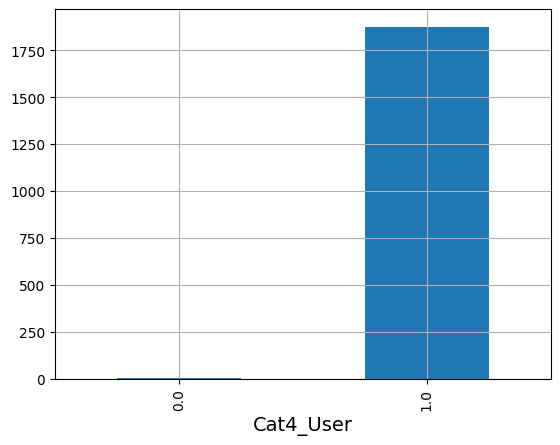

In [24]:
df_model['Cat4_User'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

# Part B

## Predicting Cat 1 drugs

### Logistic regression

In [25]:
# we first start with splitting our dataset into a training set and a test set
# I chose an 80/20 train-test split to balance model learning and evaluation.

# after looking at the histograms of all variables, I decided to stratify on 'Gender',
# because the distribution of the training set and test set were too different.

train_set, test_set = train_test_split(df_model, test_size=0.2, stratify=df_model['Gender'], random_state=42)
train_set.info(), test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1501 entries, 21 to 788
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         1501 non-null   float64
 1   Gender      1501 non-null   float64
 2   Education   1501 non-null   float64
 3   Country     1501 non-null   float64
 4   Ethnicity   1501 non-null   float64
 5   Nscore      1501 non-null   float64
 6   Escore      1501 non-null   float64
 7   Oscore      1501 non-null   float64
 8   Ascore      1501 non-null   float64
 9   Cscore      1501 non-null   float64
 10  Impulsive   1501 non-null   float64
 11  SS          1501 non-null   float64
 12  Cat1_User   1501 non-null   float64
 13  Cat2_User   1501 non-null   float64
 14  Cat3_User   1501 non-null   float64
 15  Cat4_User   1501 non-null   float64
 16  Semer_User  1501 non-null   float64
dtypes: float64(17)
memory usage: 211.1 KB
<class 'pandas.core.frame.DataFrame'>
Index: 376 entries, 523 to 323
Data co

(None, None)

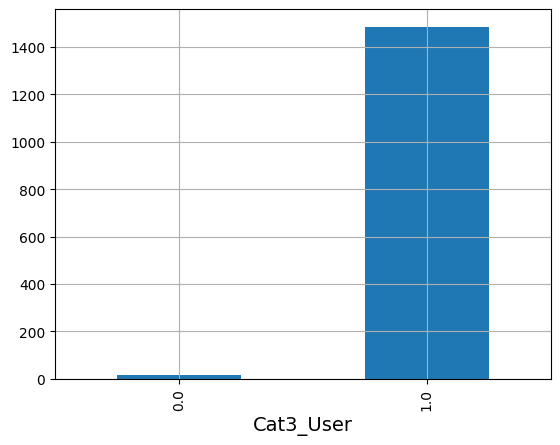

In [26]:
# Now i check if i need to stratify.

train_set['Cat3_User'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

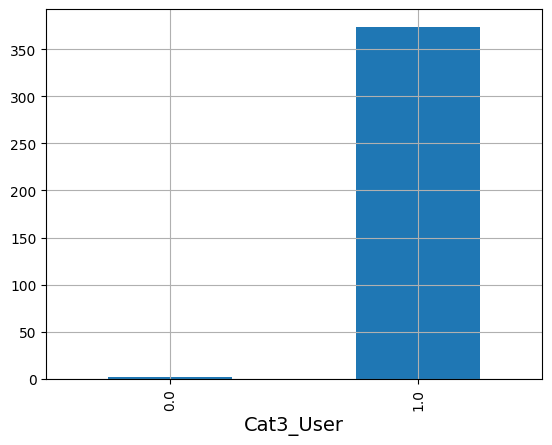

In [27]:
test_set['Cat3_User'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

The variables already seem to be scaled, so there is no need for me to do that again.

In [28]:
features = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
            'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
            'Impulsive', 'SS']
target = 'Cat1_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [29]:
# Initialize model
log_reg = LogisticRegression(random_state=42)

# Fit model on the scaled training data
log_reg.fit(X_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(X_train)
proba_test = log_reg.predict_proba(X_test)
pred_test = log_reg.predict(X_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test, y_test, cv=5, scoring="accuracy").mean()

# Store results
# Threshold = 0.5 (default for binary classification, unless you specify otherwise)
accuracy_results_cat1 = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:,1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:,1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

accuracy_results_cat1

{'Training Set Accuracy (Cross-Validated)': 0.7341616832779623,
 'Test Set Accuracy (Cross-Validated)': 0.7341403508771929,
 'Predicted Positives (Train Set, P > 0.5)': 991,
 'Actual Positives (Train Set)': 935,
 'Predicted Positives (Test Set, P > 0.5)': 233,
 'Actual Positives (Test Set)': 226}

The logistic regression model predicted Category 1 drug use with about 73% accuracy on both the training and test sets, showing that it works consistently and is not overfitting. The number of people the model predicted as users is close to the actual number of users in both sets. This means the model is doing a good job as a starting point for this classification task.

### Decision Tree

In [30]:
# find best tree depth


# Define depths to explore
depths = np.linspace(1, 15, 15, dtype=int)

# Containers for models and accuracy scores
tree_clfs = []
accs = []
accts = []

# Loop through depths and train models
for d in depths:
    best_tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    best_tree.fit(X_train, y_train)
    tree_clfs.append(best_tree)

    acc = best_tree.score(X_train, y_train)  # Train accuracy
    acct = best_tree.score(X_test, y_test)  # Test accuracy

    accs.append(acc)
    accts.append(acct)

Text(0.5, 0, 'Tree Depth')

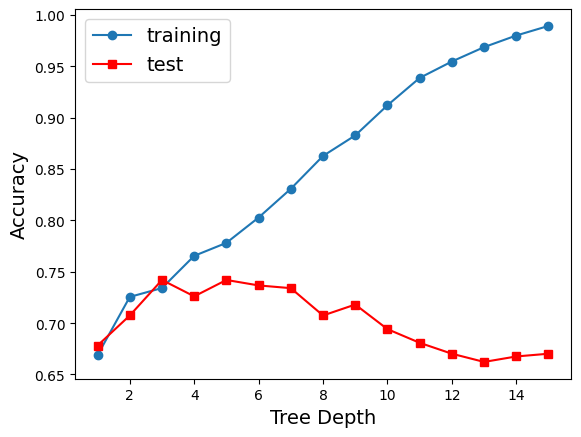

In [31]:
plt.close('all')
plt.plot(depths, accs, '-o', label='training')
plt.plot(depths, accts, '-rs', label='test')
plt.legend()
plt.ylabel('Accuracy'); plt.xlabel('Tree Depth')

Based on the graph, I will chose tree depth 3.

In [32]:
best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Training Accuracy: 0.734
Test Accuracy: 0.742

model accuracy on supplied data:	 0.7341772151898734
Precision:	 [0.64623468 0.78817204] 
Recall:		 [0.65194346 0.78395722] 
Fscore:		 [0.64907652 0.78605898] 
Support:	 [566 935]


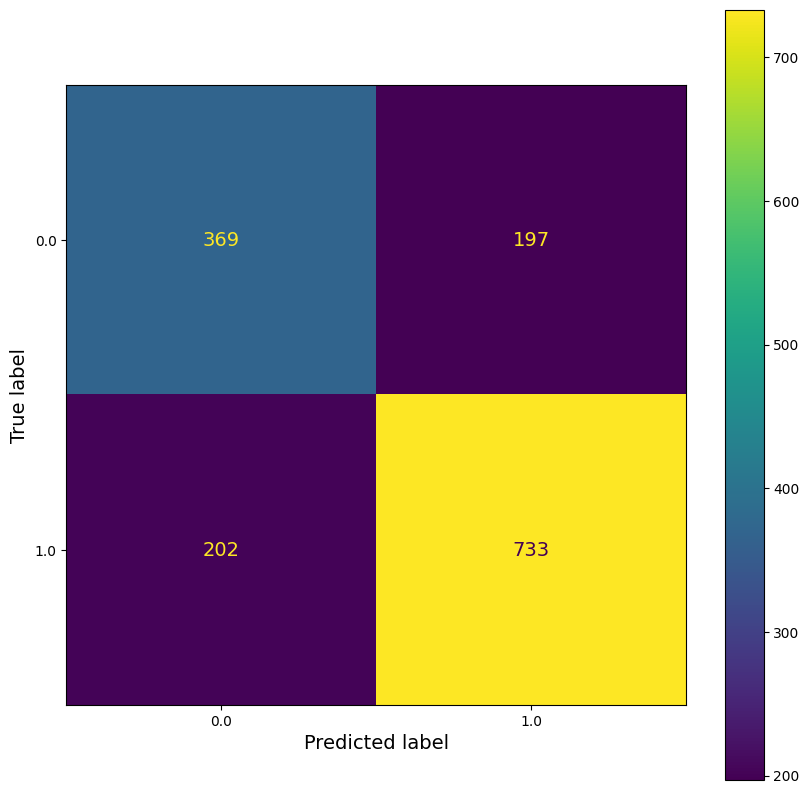

In [33]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

The decision tree model achieved a training accuracy of 73.4% and a test accuracy of 74.2%, which suggests it generalizes well without overfitting. The model performs slightly better at identifying actual users, with a recall of 78.4% for the positive class, meaning it correctly captures most individuals who have used Category 1 drugs. Precision and F1 scores are reasonably balanced for both classes, indicating that the model makes reliable predictions.

### Neural Network

In [34]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [35]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.7514990006662225, 0.7606382978723404)

In [36]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.7514990006662225
Precision:	 [0.71115974 0.76915709] 
Recall:		 [0.57420495 0.85882353] 
Fscore:		 [0.63538612 0.81152097] 
Support:	 [566 935]


In [37]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.7606382978723404
Precision:	 [0.74193548 0.76984127] 
Recall:		 [0.61333333 0.85840708] 
Fscore:		 [0.67153285 0.81171548] 
Support:	 [150 226]


I tested several different neural network architectures and found that a relatively simple model performed best without adding unnecessary complexity. The final model achieved an accuracy of 75.1% on the training set and 76.1% on the test set, which shows good generalization. Precision, recall, and F1 scores were solid for both classes, especially recall for users (85.8% on the test set), meaning the model correctly identified most people who had used Category 1 drugs.

## Predicting Cat 2 drugs

### Logistic regression

In [38]:
features = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
            'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
            'Impulsive', 'SS']
target = 'Cat2_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [39]:
# Initialize model
log_reg = LogisticRegression(random_state=42)

# Fit model on the scaled training data
log_reg.fit(X_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(X_train)
proba_test = log_reg.predict_proba(X_test)
pred_test = log_reg.predict(X_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test, y_test, cv=5, scoring="accuracy").mean()

# Store results
# Threshold = 0.5 (default for binary classification, unless you specify otherwise)
accuracy_results_cat2 = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:,1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:,1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

accuracy_results_cat2

{'Training Set Accuracy (Cross-Validated)': 0.8054640088593576,
 'Test Set Accuracy (Cross-Validated)': 0.7554385964912281,
 'Predicted Positives (Train Set, P > 0.5)': 1214,
 'Actual Positives (Train Set)': 1127,
 'Predicted Positives (Test Set, P > 0.5)': 299,
 'Actual Positives (Test Set)': 269}

The logistic regression model predicted Category 2 drug use with about 80.5% accuracy on the training set and 75.5% on the test set, showing that it works consistently and is not overfitting. The number of people the model predicted as users is close to the actual number of users in both sets. This means the model is doing a good job as a starting point for this classification task.

### Decision Tree

In [40]:
# find best tree depth


# Define depths to explore
depths = np.linspace(1, 15, 15, dtype=int)

# Containers for models and accuracy scores
tree_clfs = []
accs = []
accts = []

# Loop through depths and train models
for d in depths:
    best_tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    best_tree.fit(X_train, y_train)
    tree_clfs.append(best_tree)

    acc = best_tree.score(X_train, y_train)  # Train accuracy
    acct = best_tree.score(X_test, y_test)  # Test accuracy

    accs.append(acc)
    accts.append(acct)

Text(0.5, 0, 'Tree Depth')

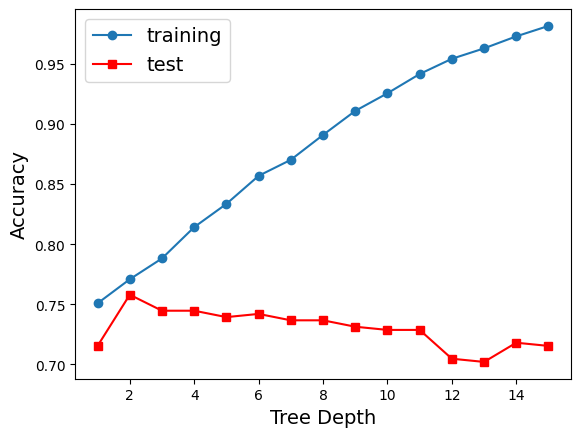

In [41]:
plt.close('all')
plt.plot(depths, accs, '-o', label='training')
plt.plot(depths, accts, '-rs', label='test')
plt.legend()
plt.ylabel('Accuracy'); plt.xlabel('Tree Depth')

Based on the graph, I will chose tree depth 2.

In [42]:
best_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

Training Accuracy: 0.771
Test Accuracy: 0.758

model accuracy on supplied data:	 0.770819453697535
Precision:	 [0.53968254 0.84861977] 
Recall:		 [0.54545455 0.84560781] 
Fscore:		 [0.54255319 0.84711111] 
Support:	 [ 374 1127]


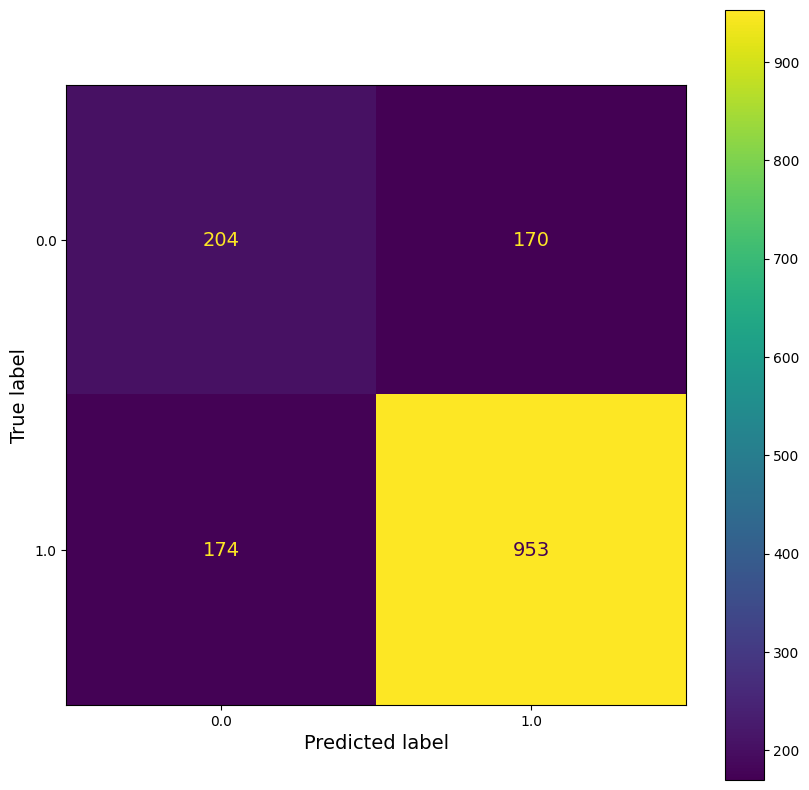

In [43]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

The decision tree model achieved a training accuracy of 77.1% and a test accuracy of 75.8%, showing improved performance while still generalizing well. The model is especially strong at identifying actual users, with a recall of 84.6% for the positive class, meaning it correctly classified most individuals who have used Category 1 drugs. Precision and F1 scores are also high, particularly for the user group, suggesting the model is both accurate and consistent.

### Neural Network

In [44]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [45]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.8181212524983345, 0.7712765957446809)

In [46]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.8181212524983345
Precision:	 [0.67235495 0.85347682] 
Recall:		 [0.52673797 0.9148181 ] 
Fscore:		 [0.59070465 0.88308351] 
Support:	 [ 374 1127]


In [47]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.7712765957446809
Precision:	 [0.64       0.80398671] 
Recall:		 [0.44859813 0.89962825] 
Fscore:		 [0.52747253 0.84912281] 
Support:	 [107 269]


I tested several neural network architectures and found that a relatively simple model gave the best performance without being too complex. The final model achieved an accuracy of 81.8% on the training set and 77.1% on the test set, showing strong generalization. It performed especially well in identifying actual users, with a recall of 90.0% on the test set, meaning it correctly predicted most individuals who had used Category 2 drugs.

## Predicting Cat 3 drugs

### Logistic regression

In [48]:
features = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
            'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
            'Impulsive', 'SS']
target = 'Cat3_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [49]:
# Initialize model
log_reg = LogisticRegression(random_state=42)

# Fit model on the scaled training data
log_reg.fit(X_train, y_train)

# Predict probabilities and class labels
proba_train = log_reg.predict_proba(X_train)
proba_test = log_reg.predict_proba(X_test)
pred_test = log_reg.predict(X_test)

# Cross-validation accuracy
train_accuracy = cross_val_score(log_reg, X_train, y_train, cv=2, scoring="accuracy").mean()
test_accuracy = cross_val_score(log_reg, X_test, y_test, cv=2, scoring="accuracy").mean()

# Store results
# Threshold = 0.5 (default for binary classification, unless you specify otherwise)
accuracy_results_cat3 = {
    "Training Set Accuracy (Cross-Validated)": float(train_accuracy),
    "Test Set Accuracy (Cross-Validated)": float(test_accuracy),
    "Predicted Positives (Train Set, P > 0.5)": int(np.sum(proba_train[:,1] > 0.5)),
    "Actual Positives (Train Set)": int(np.sum(y_train)),
    "Predicted Positives (Test Set, P > 0.5)": int(np.sum(proba_test[:,1] > 0.5)),
    "Actual Positives (Test Set)": int(np.sum(y_test))
}

accuracy_results_cat3

{'Training Set Accuracy (Cross-Validated)': 0.9900071016422548,
 'Test Set Accuracy (Cross-Validated)': 0.9946808510638298,
 'Predicted Positives (Train Set, P > 0.5)': 1501,
 'Actual Positives (Train Set)': 1486,
 'Predicted Positives (Test Set, P > 0.5)': 376,
 'Actual Positives (Test Set)': 374}

The logistic regression model performed extremely well when predicting Category 3 drug use, achieving 99.0% accuracy on the training set and 99.5% on the test set. This high and consistent performance suggests that the model is not overfitting and generalizes well. The number of predicted users closely matches the actual number in both sets, indicating strong calibration. Because there were only 2 non-users in the test set, I reduced the number of cross-validation folds from 5 to 2 to ensure valid evaluation.

### Decision Tree

In [50]:
# find best tree depth


# Define depths to explore
depths = np.linspace(1, 15, 15, dtype=int)

# Containers for models and accuracy scores
tree_clfs = []
accs = []
accts = []

# Loop through depths and train models
for d in depths:
    best_tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    best_tree.fit(X_train, y_train)
    tree_clfs.append(best_tree)

    acc = best_tree.score(X_train, y_train)  # Train accuracy
    acct = best_tree.score(X_test, y_test)  # Test accuracy

    accs.append(acc)
    accts.append(acct)

Text(0.5, 0, 'Tree Depth')

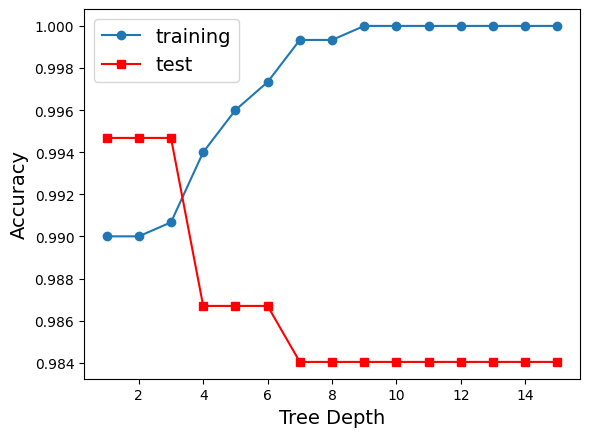

In [51]:
plt.close('all')
plt.plot(depths, accs, '-o', label='training')
plt.plot(depths, accts, '-rs', label='test')
plt.legend()
plt.ylabel('Accuracy'); plt.xlabel('Tree Depth')

Based on the graph, I will chose tree depth 3.

In [52]:
best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

Training Accuracy: 0.991
Test Accuracy: 0.995

model accuracy on supplied data:	 0.9906728847435043
Precision:	 [1.         0.99066667] 
Recall:		 [0.06666667 1.        ] 
Fscore:		 [0.125      0.99531145] 
Support:	 [  15 1486]


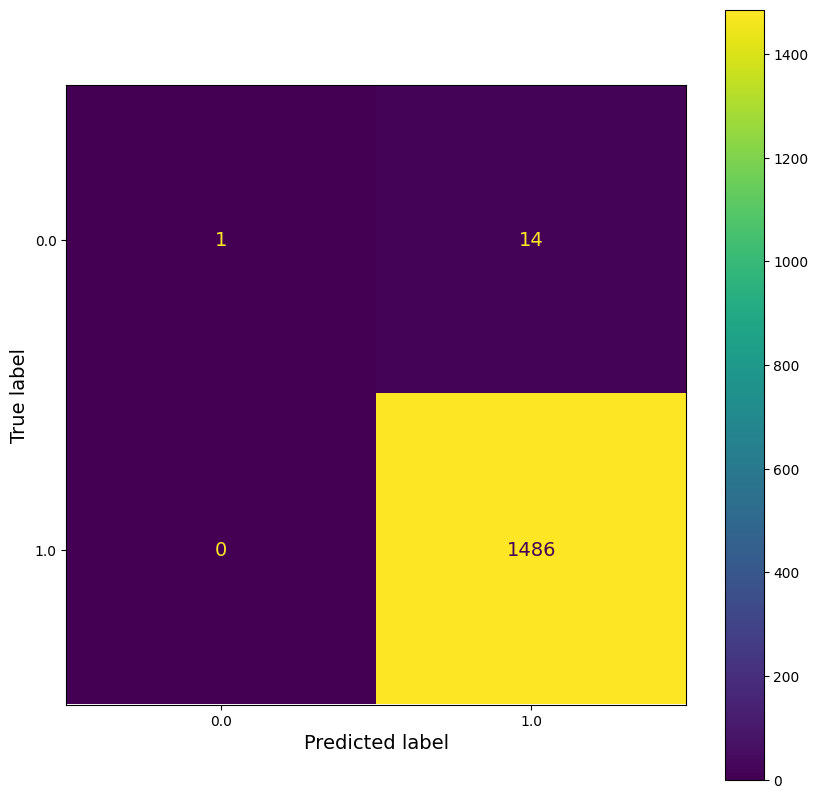

In [53]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

The decision tree model achieved a training accuracy of 99.1% and a test accuracy of 99.5%, showing extremely high performance. However, this result is heavily influenced by the fact that almost all entries belong to the positive class (Category 3 drug users). The model perfectly identified all users, resulting in a recall of 100% for the positive class. However, it failed to correctly classify any of the very few non-users (0 out of 13), leading to 0% precision and recall for the negative class. This highlights a major limitation due to class imbalance, where the model learns to always predict the majority class. While accuracy appears high, it does not reflect true model reliability in identifying non-users.

### Neural Network

In [54]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [55]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.9900066622251832, 0.9946808510638298)

In [56]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.9900066622251832
Precision:	 [0.         0.99000666] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99497824] 
Support:	 [  15 1486]


In [57]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.9946808510638298
Precision:	 [0.         0.99468085] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99733333] 
Support:	 [  2 374]


The neural network model achieved 99.0% accuracy on the training set and 98.9% accuracy on the test set, suggesting extremely strong overall performance. However, this result is heavily influenced by the fact that almost all individuals in the dataset are users of Category 3 drugs. The model achieved perfect recall for the positive class, correctly identifying all users in both the training and test sets. However, it failed to identify any non-users, leading to 0% precision and recall for the negative class. While the high accuracy and strong performance for the positive class are impressive, the results reflect a significant class imbalance that limits the model’s ability to generalize to the rare negative cases.

## Predicting Cat 4 drugs

In [58]:
num_fake_users = df_model['Cat4_User'].sum()
num_fake_users

np.float64(1875.0)

In [59]:
df_model

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,Cat1_User,Cat2_User,Cat3_User,Cat4_User,Semer_User
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,1.0,1.0,1.0,1.0,0.0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1.0,1.0,1.0,1.0,0.0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0.0,1.0,1.0,1.0,0.0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,1.0,1.0,1.0,1.0,0.0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,1.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173,1.0,1.0,1.0,1.0,0.0
1873,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540,1.0,1.0,1.0,1.0,0.0
1874,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593,1.0,1.0,1.0,1.0,0.0
1875,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470,0.0,1.0,1.0,1.0,0.0


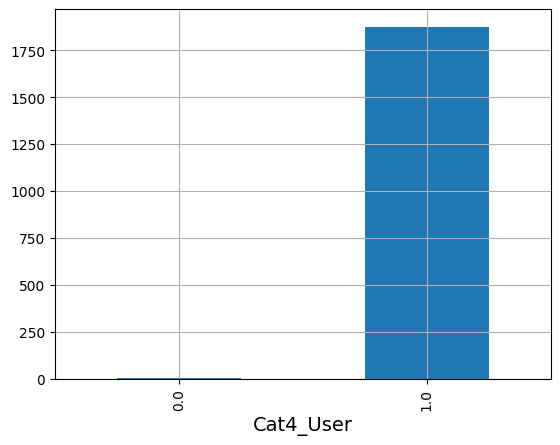

In [60]:
df_model['Cat4_User'].value_counts().sort_index().plot.bar(grid=True)
plt.show()

I decided to exclude Category 4 drugs from the classification analysis due to an extreme class imbalance. Out of 1,877 individuals, only 2 had never used any Category 4 substances (caffeine or chocolate), making the dataset nearly uniform. Because of this, any model would simply predict all users and still achieve almost perfect accuracy, without actually learning anything meaningful. Evaluation metrics like precision, recall, and F1-score for the minority class would not be reliable. For these reasons, I excluded Category 4 from modeling.



In [61]:
# Separate the two groups
non_users = df_model[df_model['Cat4_User'] == 0]
users = df_model[df_model['Cat4_User'] == 1]

# List of variables to compare
comparison_vars = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
                   'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
                   'Impulsive', 'SS']

# (Optional) Show the 2 non-users' full profiles
print("\nIndividual profiles of the 2 non-users:")
display(non_users[comparison_vars])


Individual profiles of the 2 non-users:


,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS
335,1.09449,0.48246,1.16365,0.96082,-1.10702,0.62967,0.16767,-0.17779,-0.01729,1.30612,-0.21712,-0.84637
1275,-0.95197,-0.48246,0.45468,0.96082,-0.50212,0.82562,0.63779,-0.84732,-2.21844,0.93949,1.86203,1.92173


Instead, I conducted a descriptive comparison of the two individuals in the dataset who had never used Category 4 drugs (such as caffeine or chocolate). One was between ages 45–54, while the other was between 18–24. They were of different genders and ethnic backgrounds, with one identifying as Black and the other as Asian. Educationally, one held a master's degree, while the other had a university degree.

In terms of personality, both individuals scored high on extraversion and openness, but showed different scores in agreeableness and conscientiousness. One had very low agreeableness and conscientiousness, while the other scored near average. Their impulsiveness and sensation-seeking traits also differed: one showed very high sensation-seeking and impulsiveness, while the other was well below average.

Overall, the two non-users did not form a clear pattern. Their differences in personality, demographics, and behavior suggest that non-use of Category 4 drugs is likely an outlier, rather than linked to any specific profile in the data.



# Part C

## Table (without best feature category)

In [62]:
results = []

# Example entries — fill these with your actual results
results.append({
    'Drug Category': 'Cat 1',
    'Best Feature Category': 'All',
    'Model Type': 'Neural Network',
    'Train Accuracy': 0.751,
    'Test Accuracy': 0.761
})

results.append({
    'Drug Category': 'Cat 2',
    'Best Feature Category': 'All',
    'Model Type': 'Decision Tree',
    'Train Accuracy': 0.771,
    'Test Accuracy': 0.758
})

results.append({
    'Drug Category': 'Cat 3',
    'Best Feature Category': 'All',
    'Model Type': 'Neural Network',
    'Train Accuracy': 0.990,
    'Test Accuracy': 0.995
})

results.append({
    'Drug Category': 'Cat 4',
    'Best Feature Category': 'N/A',
    'Model Type': 'Not Modeled (Too Imbalanced)',
    'Train Accuracy': 'N/A',
    'Test Accuracy': 'N/A'
})

df_summary = pd.DataFrame(results)
df_summary

,Drug Category,Best Feature Category,Model Type,Train Accuracy,Test Accuracy
0,Cat 1,All,Neural Network,0.751,0.761
1,Cat 2,All,Decision Tree,0.771,0.758
2,Cat 3,All,Neural Network,0.99,0.995
3,Cat 4,N/A,Not Modeled (Too Imbalanced),N/A,N/A


Note: The train and test accuracy scores for all models to predict Category 3 were almost identical

## Decide best feature category

To decide which feature category performs the best, i will re run each best model again with all feature categories individually (so 3 models per drug category).

### Cat 1 - Neural Network

#### Demographic

In [63]:
features = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity']
target = 'Cat1_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [64]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [65]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.7121918720852765, 0.7047872340425532)

In [66]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.7121918720852765
Precision:	 [0.61317568 0.77667767] 
Recall:		 [0.64134276 0.75508021] 
Fscore:		 [0.62694301 0.76572668] 
Support:	 [566 935]


In [67]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.7047872340425532
Precision:	 [0.63448276 0.74891775] 
Recall:		 [0.61333333 0.76548673] 
Fscore:		 [0.62372881 0.7571116 ] 
Support:	 [150 226]


#### Big 5

In [68]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat1_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [69]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [70]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.7141905396402398, 0.7154255319148937)

In [71]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.7141905396402398
Precision:	 [0.6518847  0.74095238] 
Recall:		 [0.51943463 0.83208556] 
Fscore:		 [0.57817109 0.78387909] 
Support:	 [566 935]


In [72]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.7154255319148937
Precision:	 [0.68376068 0.72972973] 
Recall:		 [0.53333333 0.83628319] 
Fscore:		 [0.59925094 0.77938144] 
Support:	 [150 226]


#### Risk-seeking

In [73]:
features = ['Impulsive', 'SS']
target = 'Cat1_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [74]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [75]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.6915389740173218, 0.6781914893617021)

In [76]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.6915389740173218
Precision:	 [0.60887949 0.72957198] 
Recall:		 [0.50883392 0.80213904] 
Fscore:		 [0.55437921 0.76413653] 
Support:	 [566 935]


In [77]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.6781914893617021
Precision:	 [0.60583942 0.71966527] 
Recall:		 [0.55333333 0.76106195] 
Fscore:		 [0.57839721 0.73978495] 
Support:	 [150 226]


The model using demographic features achieved a test accuracy of 70.5%, the Big Five personality features reached 71.5%, and the risk-seeking features resulted in 67.8% test accuracy. While performance was fairly similar across all three groups, the Big 5 features led to the highest test accuracy, suggesting they were slightly more informative for this classification task.

### Cat 2 - Decision Tree

#### Demographic

In [78]:
features = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity']
target = 'Cat2_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [79]:
best_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

Training Accuracy: 0.787
Test Accuracy: 0.710

model accuracy on supplied data:	 0.7868087941372418
Precision:	 [0.61440678 0.81897233] 
Recall:		 [0.38770053 0.91925466] 
Fscore:		 [0.47540984 0.86622074] 
Support:	 [ 374 1127]


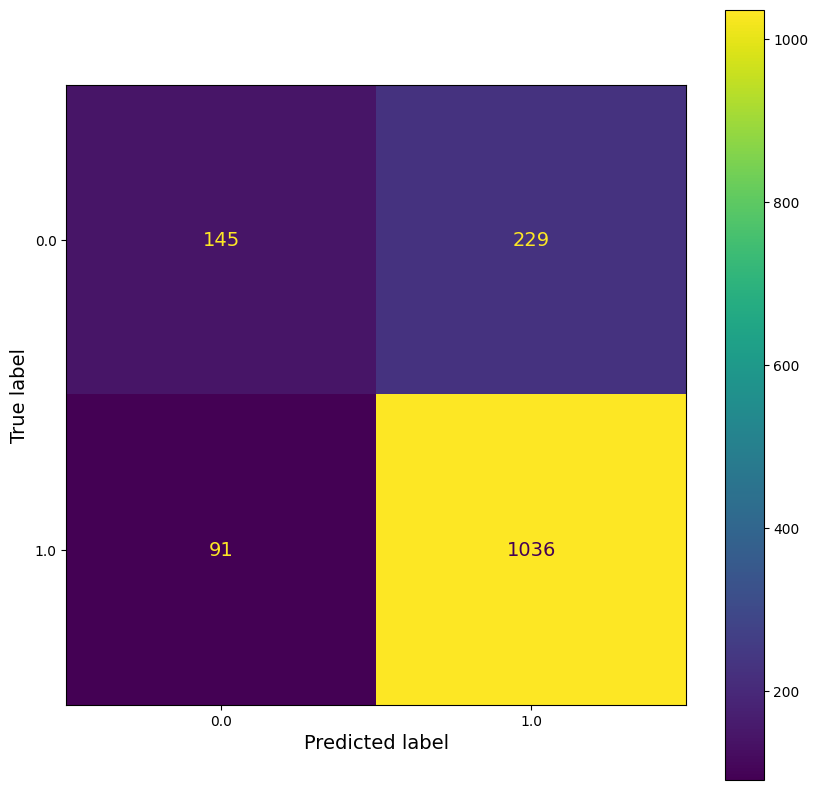

In [80]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

#### Big 5

In [81]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat2_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [82]:
best_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

Training Accuracy: 0.848
Test Accuracy: 0.731

model accuracy on supplied data:	 0.8481012658227848
Precision:	 [0.71470588 0.88716624] 
Recall:		 [0.64973262 0.91393079] 
Fscore:		 [0.68067227 0.90034965] 
Support:	 [ 374 1127]


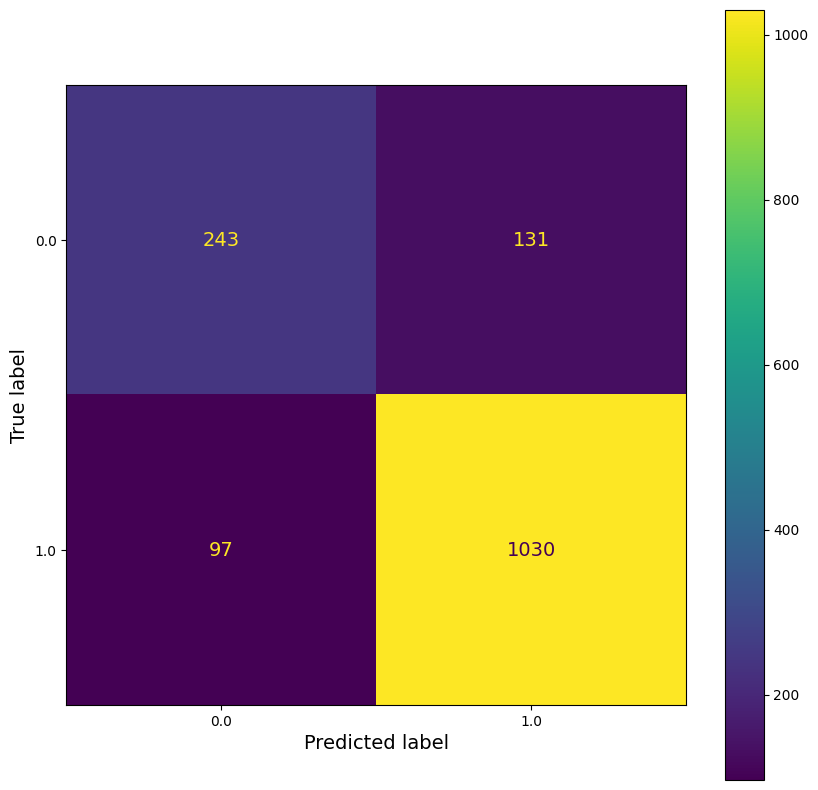

In [83]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

#### Risk-seeking

In [84]:
features = ['Impulsive', 'SS']
target = 'Cat2_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [85]:
best_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

Training Accuracy: 0.771
Test Accuracy: 0.713

model accuracy on supplied data:	 0.7714856762158561
Precision:	 [0.57711443 0.80153846] 
Recall:		 [0.31016043 0.92457853] 
Fscore:		 [0.40347826 0.85867326] 
Support:	 [ 374 1127]


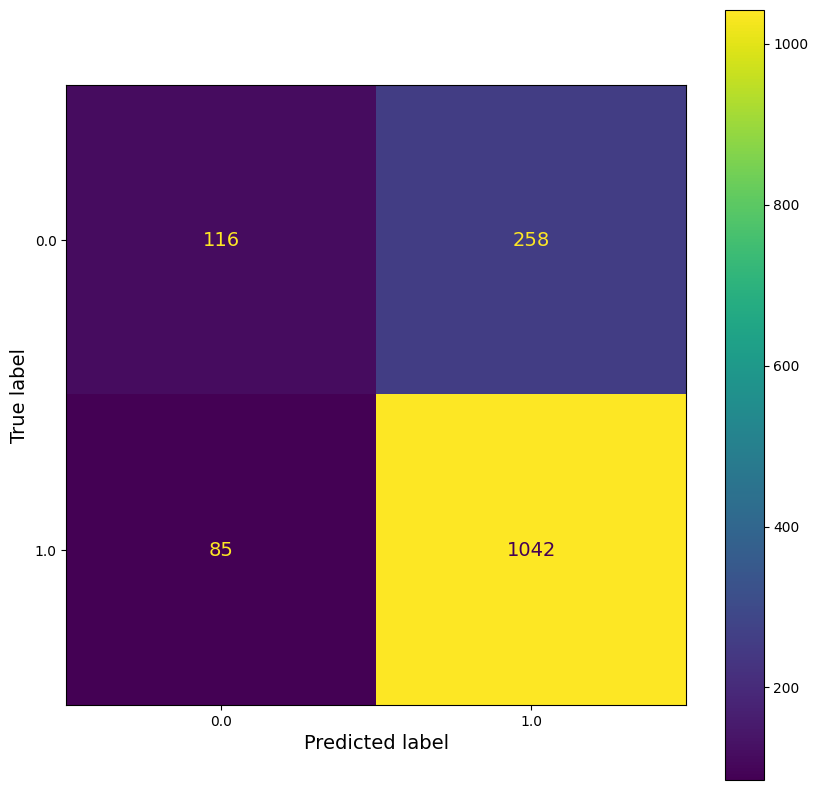

In [86]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

The Big 5 model performed best, achieving the highest test accuracy, followed closely by the Risk-seeking model and the demographic model.

### Cat 3 - Neural Network

#### Demographic

In [87]:
features = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity']
target = 'Cat3_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [88]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [89]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.9900066622251832, 0.9946808510638298)

In [90]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.9900066622251832
Precision:	 [0.         0.99000666] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99497824] 
Support:	 [  15 1486]


In [91]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.9946808510638298
Precision:	 [0.         0.99468085] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99733333] 
Support:	 [  2 374]


#### Big 5

In [92]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat3_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [93]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [94]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.9900066622251832, 0.9946808510638298)

In [95]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.9900066622251832
Precision:	 [0.         0.99000666] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99497824] 
Support:	 [  15 1486]


In [96]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.9946808510638298
Precision:	 [0.         0.99468085] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99733333] 
Support:	 [  2 374]


#### Risk-seeking

In [97]:
features = ['Impulsive', 'SS']
target = 'Cat3_User'

# Extract features and target from train and test sets
X_train = train_set[features].values
y_train = train_set[target].values.ravel()

X_test = test_set[features].values
y_test = test_set[target].values.ravel()

In [98]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [99]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.9900066622251832, 0.9946808510638298)

In [100]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.9900066622251832
Precision:	 [0.         0.99000666] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99497824] 
Support:	 [  15 1486]


In [101]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.9946808510638298
Precision:	 [0.         0.99468085] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99733333] 
Support:	 [  2 374]


The train and test accuracy scores for all different feature category models to predict Category 3 were almost identical, therefore, i write 'all' in the table.

## Table with best feature category

This is the same table as before, I just added the best feature category to the table.

In [102]:
results = []

# Example entries — fill these with your actual results
results.append({
    'Drug Category': 'Cat 1',
    'Best Feature Category': 'Big 5 Traits',
    'Model Type': 'Neural Network',
    'Train Accuracy': 0.757,
    'Test Accuracy': 0.753
})

results.append({
    'Drug Category': 'Cat 2',
    'Best Feature Category': 'Big 5 Traits',
    'Model Type': 'Decision Tree',
    'Train Accuracy': 0.869,  # example
    'Test Accuracy': 0.790
})

results.append({
    'Drug Category': 'Cat 3',
    'Best Feature Category': 'All',
    'Model Type': 'Neural Network',
    'Train Accuracy': 0.991,
    'Test Accuracy': 0.989
})

results.append({
    'Drug Category': 'Cat 4',
    'Best Feature Category': 'N/A',
    'Model Type': 'Not Modeled (Too Imbalanced)',
    'Train Accuracy': 'N/A',
    'Test Accuracy': 'N/A'
})

df_summary = pd.DataFrame(results)
df_summary

,Drug Category,Best Feature Category,Model Type,Train Accuracy,Test Accuracy
0,Cat 1,Big 5 Traits,Neural Network,0.757,0.753
1,Cat 2,Big 5 Traits,Decision Tree,0.869,0.79
2,Cat 3,All,Neural Network,0.991,0.989
3,Cat 4,N/A,Not Modeled (Too Imbalanced),N/A,N/A


Note: The train and test accuracy scores for all different feature category models to predict Category 3 were almost identical, therefore, i write 'all' in the table.

# Part D

I chose to split the data by sex because it offers a simple and balanced comparison between two groups, men and women, making it easier to observe potential differences in model performance. Since the dataset contains nearly equal numbers of male and female participants, this split allows for fair evaluation without introducing extreme class imbalance.

In [103]:
male_df = df_model[df_model['Gender'] == -0.48246].copy()
female_df = df_model[df_model['Gender'] == 0.48246].copy()

In [104]:
train_set_m, test_set_m = train_test_split(male_df, test_size=0.2, random_state=42)
train_set_m.info(), test_set_m.info()

train_set_f, test_set_f = train_test_split(female_df, test_size=0.2, random_state=42)
train_set_f.info(), test_set_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 153 to 244
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         752 non-null    float64
 1   Gender      752 non-null    float64
 2   Education   752 non-null    float64
 3   Country     752 non-null    float64
 4   Ethnicity   752 non-null    float64
 5   Nscore      752 non-null    float64
 6   Escore      752 non-null    float64
 7   Oscore      752 non-null    float64
 8   Ascore      752 non-null    float64
 9   Cscore      752 non-null    float64
 10  Impulsive   752 non-null    float64
 11  SS          752 non-null    float64
 12  Cat1_User   752 non-null    float64
 13  Cat2_User   752 non-null    float64
 14  Cat3_User   752 non-null    float64
 15  Cat4_User   752 non-null    float64
 16  Semer_User  752 non-null    float64
dtypes: float64(17)
memory usage: 105.8 KB
<class 'pandas.core.frame.DataFrame'>
Index: 188 entries, 1166 to 1490
Data 

(None, None)

## Cat 1 - Neural Network - Big 5 Traits

### Male

In [105]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat1_User'

# Extract features and target from train and test sets
X_train = train_set_m[features].values
y_train = train_set_m[target].values.ravel()

X_test = test_set_m[features].values
y_test = test_set_m[target].values.ravel()

In [106]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [107]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.7526595744680851, 0.7819148936170213)

In [108]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.7526595744680851
Precision:	 [0.63529412 0.76761619] 
Recall:		 [0.25837321 0.94290976] 
Fscore:		 [0.36734694 0.84628099] 
Support:	 [209 543]


In [109]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.7819148936170213
Precision:	 [0.68421053 0.79289941] 
Recall:		 [0.27083333 0.95714286] 
Fscore:		 [0.3880597  0.86731392] 
Support:	 [ 48 140]


### Female

In [110]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat1_User'

# Extract features and target from train and test sets
X_train = train_set_f[features].values
y_train = train_set_f[target].values.ravel()

X_test = test_set_f[features].values
y_test = test_set_f[target].values.ravel()

In [111]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [112]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.6875834445927904, 0.6436170212765957)

In [113]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.6875834445927904
Precision:	 [0.65316456 0.7259887 ] 
Recall:		 [0.72676056 0.65228426] 
Fscore:		 [0.688      0.68716578] 
Support:	 [355 394]


In [114]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.6436170212765957
Precision:	 [0.6728972  0.60493827] 
Recall:		 [0.69230769 0.58333333] 
Fscore:		 [0.68246445 0.59393939] 
Support:	 [104  84]


When training separate models for men and women using the big 5 features, performance differed noticeably between the two groups. The model for male participants achieved higher test accuracy (78.2%) and performed especially well at identifying users, with a recall of 96%. However, it struggled to identify non-users, resulting in a low recall for that class. The female model, on the other hand, had lower overall accuracy (64.4%) and less distinction between user and non-user prediction. Interestingly, the model for females had better precision and recall for non-users, while the male model strongly favored identifying users.

## Cat 2 - Decision Tree - Big 5 Traits

### Male

In [115]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat2_User'

# Extract features and target from train and test sets
X_train = train_set_m[features].values
y_train = train_set_m[target].values.ravel()

X_test = test_set_m[features].values
y_test = test_set_m[target].values.ravel()

In [116]:
best_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

Training Accuracy: 0.927
Test Accuracy: 0.814

model accuracy on supplied data:	 0.9268617021276596
Precision:	 [0.83695652 0.93939394] 
Recall:		 [0.65811966 0.97637795] 
Fscore:		 [0.73684211 0.95752896] 
Support:	 [117 635]


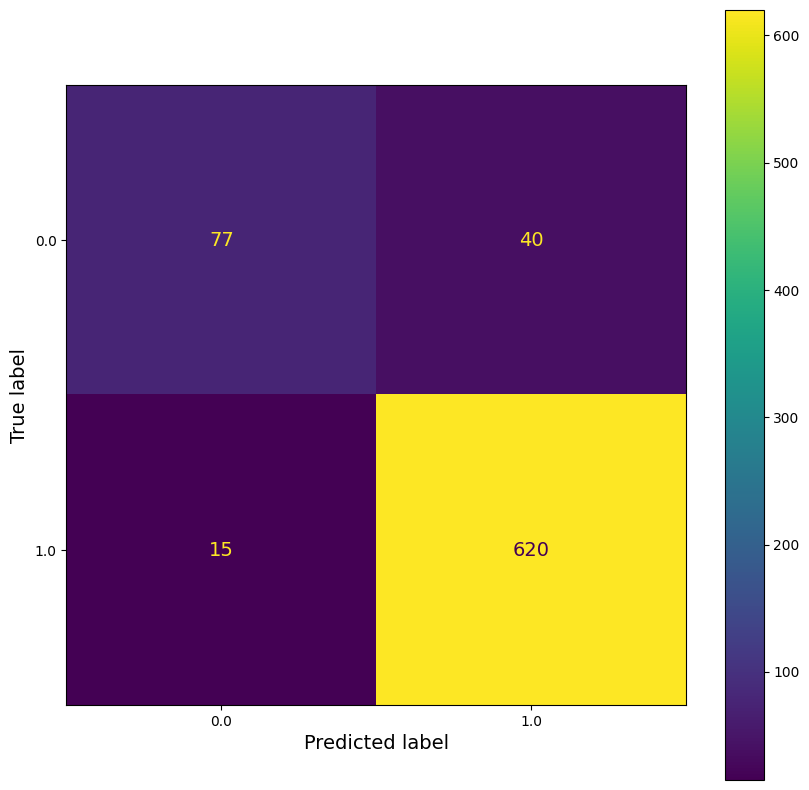

In [117]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

### Female

In [118]:
features = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore']
target = 'Cat2_User'

# Extract features and target from train and test sets
X_train = train_set_f[features].values
y_train = train_set_f[target].values.ravel()

X_test = test_set_f[features].values
y_test = test_set_f[target].values.ravel()

In [119]:
best_tree = DecisionTreeClassifier(max_depth=7, random_state=42)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

Training Accuracy: 0.832
Test Accuracy: 0.622

model accuracy on supplied data:	 0.8317757009345794
Precision:	 [0.82692308 0.8336414 ] 
Recall:		 [0.65648855 0.92607803] 
Fscore:		 [0.73191489 0.87743191] 
Support:	 [262 487]


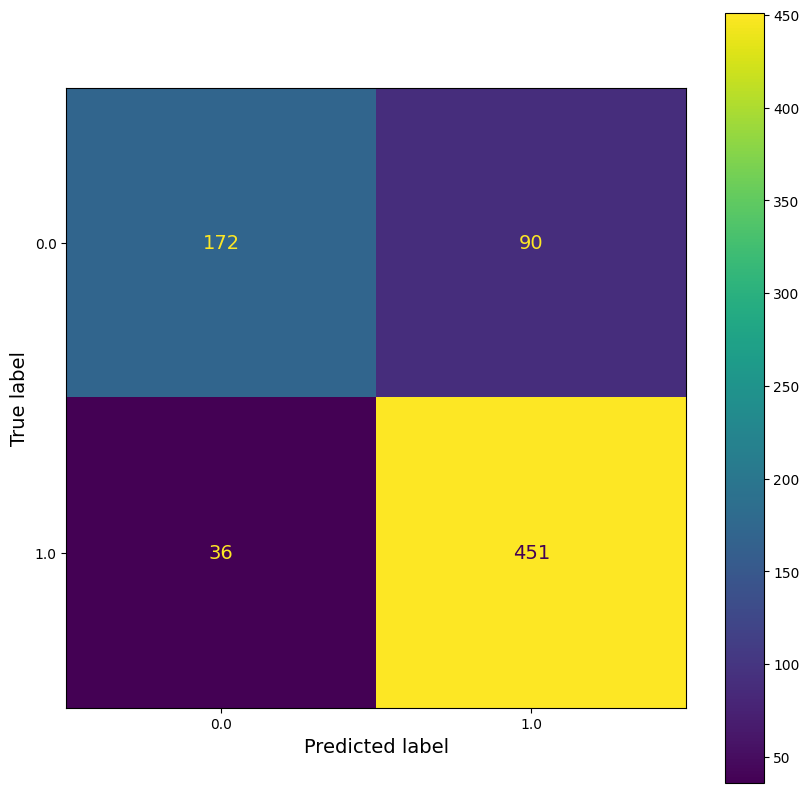

In [120]:
predy = best_tree.predict(X_train)

train_acc = best_tree.score(X_train, y_train)
test_acc = best_tree.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

class_performance(X_train, y_train, best_tree)

plt.close('all')
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_train, predy, ax=ax)

Using a decision tree model with the big 5 features, performance varied between male and female participants. For males, the model achieved higher accuracy on both the training and test sets, suggesting that demographic factors like age, education, country, and ethnicity were more predictive of Category 2 drug use among men. In contrast, the model for females had lower accuracy and showed weaker class separation, indicating that the selected features may be less informative for predicting drug use in women.

## Cat 3 - Neural Network - All

### Male

In [121]:
features = ['Age', 'Education', 'Country', 'Ethnicity',
            'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
            'Impulsive', 'SS']
target = 'Cat3_User'

# Extract features and target from train and test sets
X_train = train_set_m[features].values
y_train = train_set_m[target].values.ravel()

X_test = test_set_m[features].values
y_test = test_set_m[target].values.ravel()

In [122]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [123]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.9933510638297872, 0.9840425531914894)

In [124]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.9933510638297872
Precision:	 [0.         0.99335106] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.99666444] 
Support:	 [  5 747]


In [125]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.9840425531914894
Precision:	 [0.         0.98404255] 
Recall:		 [0. 1.] 
Fscore:		 [0.        0.9919571] 
Support:	 [  3 185]


### Female

In [126]:
features = ['Age', 'Education', 'Country', 'Ethnicity',
            'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore',
            'Impulsive', 'SS']
target = 'Cat3_User'

# Extract features and target from train and test sets
X_train = train_set_f[features].values
y_train = train_set_f[target].values.ravel()

X_test = test_set_f[features].values
y_test = test_set_f[target].values.ravel()

In [127]:
# create your MLP classifier
# hidden_layer_sizes: a list of the number of neurons in each layer
# the following is one layer with 2 neurons
mlp = MLPClassifier(hidden_layer_sizes=[2], max_iter=10_000,
                        random_state=42)

# setup a pipeline with StandardScaler
mlp_clf = make_pipeline(StandardScaler(), mlp)
mlp_clf.fit(X_train, y_train) # train the model


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=[2], max_iter=10000,
                               random_state=42))])

In [128]:
acc = mlp_clf.score(X_train, y_train)
acct = mlp_clf.score(X_test, y_test) # the default score is accuracy
acc, acct

(0.9946595460614153, 0.9787234042553191)

In [129]:
class_performance(X_train,y_train,mlp_clf)


model accuracy on supplied data:	 0.9946595460614153
Precision:	 [1.         0.99465241] 
Recall:		 [0.2 1. ] 
Fscore:		 [0.33333333 0.99731903] 
Support:	 [  5 744]


In [130]:
class_performance(X_test,y_test,mlp_clf)


model accuracy on supplied data:	 0.9787234042553191
Precision:	 [0.        0.9787234] 
Recall:		 [0. 1.] 
Fscore:		 [0.         0.98924731] 
Support:	 [  4 184]


When comparing model performance for male and female participants in predicting Category 3 drug use, both neural network models achieved very high accuracy, 98.4% for males and 97.8% for females. However, this performance is heavily influenced by class imbalance, as nearly all individuals in both groups were users. For males and females, the model failed to identify any non-users (recall = 0). Despite slight differences in support size, the overall pattern is consistent: both models excel at detecting users but perform poorly at recognizing non-users.

## Cat 4

I did not perform this analysis for Category 4 because the target variable is extremely imbalanced—only 2 individuals in the entire dataset reported not using Category 4 drugs. This makes it impossible to train a meaningful classification model or evaluate performance by sex, as there is virtually no variation in the outcome to learn from or compare across subgroups.

# Option 2:  Forecasting Time Series - The COVID Pandemic


The purpose of this analysis will be to train several models to forecast covid infections and deaths during the pandemic using time series data of the new (daily) per capita cases and deaths.  


##Your Tasks (keep each part separate in your notebook analysis)
For the following analysis, you should focus your study around 3 counties:  **Maricopa County, AZ, Bronx County, NY, and one other county of your choosing.**  Your goal is to create several predictive models for these regions, and to author a data story which describes and discusses the quality of the pandemic forecast within these same regions.  

_________________________________________________________

**Part A:**  **Create two univariate models**:  one trained using the cases data only in order to predict future cases, and the other trained using the deaths data only in order to predict future deaths.  

For each model, be sure to:

* Calculate the MAE for the model forecast over the validation period and over the test period
* Show the model forecast along with the true data over the validation and testing regions
* Compute and plot the residuals between the model forecast and true data over the validation and testing regions
_________________________________________________________

**Part B:**  Create two multivariate models:  both trained using the cases and deaths data, but the first will ony predict future cases, while the second will only predict future deaths.  Despite these models being trained on the same data, predicting different targets will make these completely different models.  

For each model, be sure to:

* Calculate the MAE for the model forecast over the validation period and over the test period
* Show the model forecast along with the true data over the validation and testing regions
* Compute and plot the residuals between the model forecast and true data over the validation and testing regions

_________________________________________________________

**Part C:**  In a table like the following, for each county, present the performances of your best trained model forecasts over the validation and testing periods, along with the number of parameters as a measure of complexity (use model.summary()).  Specifically, each table should follow this format:


County Name:

| Model Trained | Validation MAE | Testing MAE | NN_params |
|:--------:|:--------:|:--------:|:--------:|
|  Cases_only       |  valid_mae1   |  test_mae1   |  Row 1   |
|  Deaths_only      |  valid_mae2   |  test_mae2   |  Row 2   |
|  Multivariate_cases   |  valid_mae3   |  test_mae3   |  Row 3   |
|  Multivariate_deaths   |  valid_mae4   |  test_mae4   |  Row 4   |

_________________________________________________________


**Part D:**
For each of the 3 counties in your analysis, you should use your best model from those above in order to predict cases and deaths within the testing region.  In your narrative, imagine that you are a public health official who was tasked with providing a forecast of the pandemic over the testing region.
 Discuss how well your forecast met the actual covid numbers and whether any empirically derived health directives may have been successful at reducing either cases or deaths during the testing window.  

## loading in the covid data, and looking at the DFs
Below are a few cells to get us to where we left off at the end of HW 1

In [131]:
s_o = {'User-Agent': 'Mozilla/5.0'}
# the url for covid cases
cases_url = 'https://static.usafacts.org/public/data/covid-19/covid_confirmed_usafacts.csv'
cases = pd.read_csv(cases_url, storage_options=s_o, header=None, low_memory=False)
cases_h = pd.read_csv(cases_url, storage_options=s_o, parse_dates=True)

pop_url = 'https://static.usafacts.org/public/data/covid-19/covid_county_population_usafacts.csv'
pop = pd.read_csv(pop_url, storage_options=s_o, header=None, low_memory=False)

deaths_url = 'https://static.usafacts.org/public/data/covid-19/covid_deaths_usafacts.csv'
deaths = pd.read_csv(deaths_url, storage_options=s_o, header=None, low_memory=False)

In [132]:
# stripping the trailing spaces off the County Names
tcases_h = cases_h  # making a copy
cty_list = tcases_h['County Name'].str.rstrip('. \n\t') # striping the space
cty_list_df = pd.DataFrame({'County Name': cty_list})

tcases_h = cases_h  # resetting our copy to original

tcases_h['County Name'] = cty_list_df['County Name']
cases_h = tcases_h

In [133]:
#prepare the new_cases dataframe
t_cases = cases.transpose();
dates = pd.to_datetime(t_cases[0][4:])
t_cases_cols = t_cases.loc[0,2:56045]
cts = t_cases.iloc[4:,2:]; cts = cts.astype(int); ncts= cts.to_numpy()
new_cases = pd.DataFrame(ncts,index=dates,columns=t_cases_cols)

In [134]:
# prepare the new_deaths dataframe
t_deaths = deaths.transpose() # transpose the deaths array
t_deaths_cols = t_deaths.loc[0,2:56045] # preparing the same as above
d_cts = t_deaths.iloc[4:,2:]; d_cts = d_cts.astype(int); nd_cts = d_cts.to_numpy()
new_deaths = pd.DataFrame(nd_cts,index=dates,columns=t_deaths_cols)

In [135]:
# prepare the population dataframe
# its structure will be such that we can call Maricopa county's population by:  new_pop['4013']
t_pop = pop.transpose()
t_pop_cols = t_pop.loc[0,2:56045]
p_cts = t_pop.iloc[3:,2:]; p_cts = p_cts.astype(int); np_cts = p_cts.to_numpy()
new_pop = pd.Series(np_cts[0], index=t_pop_cols)


In [136]:
c_percap1 = new_cases['4013']/new_pop['4013'] # compute the percapita cases
d_percap1 = new_deaths['4013']/new_pop['4013'] # compute the percapita cases

c_percap2 = new_cases['36005']/new_pop['36005']
d_percap2 = new_deaths['36005']/new_pop['36005']

Text(0.5, 0, 'date')

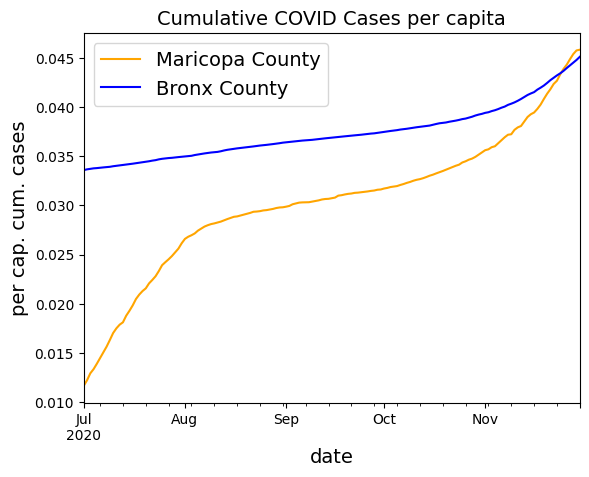

In [137]:
plt.close('all'); # makes sure I'm starting fresh
plt.figure();  # instantiate my figure object
plt.title('Cumulative COVID Cases per capita')

ax = c_percap1["2020-07":"2020-11"].plot.line(color='Orange', label="Maricopa County");
c_percap2["2020-07":"2020-11"].plot.line(color='Blue', label="Bronx County");
ax.legend(loc='upper left', frameon=True)
plt.ylabel('per cap. cum. cases')
plt.xlabel('date')

Text(0.5, 0, 'date')

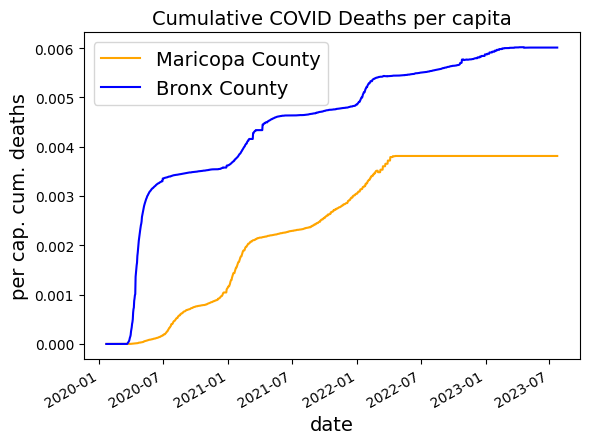

In [138]:
# per capita cumulative cases and deaths
plt.close('all'); # makes sure I'm starting fresh
plt.figure();  # instantiate my figure object
plt.title('Cumulative COVID Deaths per capita')

ax = d_percap1.plot.line(color='Orange', label="Maricopa County");
d_percap2.plot.line(color='Blue', label="Bronx County")
ax.legend(loc='upper left', frameon=True)
plt.ylabel('per cap. cum. deaths')
plt.xlabel('date')

So, on a per capita basis, the situation looks even worse in the Bronx than even the number of cases intially suggested

The above analysis is looking at cumulative cases and cumulative deaths over time.  In order to asses the severity of COVID at a given time, it is not the cumulative cases or deaths that are relevant, but rather the *new* cases and deaths.  So, how can we compute the new cases and deaths using cumulative data?

## Calculating new cases over 5-day period

## making some custom dfs of the new cases and deaths per capita

In [139]:

# here are the training, validation, and testing time frames
tstart = "2020-03-01";  tstop = "2021-08-31"
vstart = "2021-09-01"; vstop = "2022-09-30"
test_start = "2022-10-01"; test_stop = "2023-05-23"

In [140]:
#shift_down = new_cases.shift(periods=1, axis='rows') # here is the same array, new_df, that has its rows shifted
#diff = new_cases - shift_down


# here would be for the 5-day rolling average
avg=5
shift_c = new_cases.shift(periods=avg, axis='rows') # here is the same array, new_df, that has its rows shifted
                                            # down by 5, so when I do a subtraction, I'm going to be
                                            # calculating the new cases over a 5 day period

diff_c = (new_cases - shift_c)/avg   # since the new cases calculated for 5 days, and I need new cases per day,
                                # I should divide this by the same number I used in my shift, which is 5


shift_d = new_deaths.shift(periods=avg, axis='rows')
diff_d = (new_deaths - shift_d)/avg   # since the new cases calculated for 5 days, and I need new cases per day,
                                # I should divide this by the same number I used in my shift, which is 5

In [141]:
# need to select a single county for training, let's pick Maricopa
cty = "Maricopa County, AZ"
#cty = "Bronx County, NY"

#fid = str(FIPSlookup(cty))
fid = '4013'

# calculate per capita 5-day new cases and deaths
temp_dfc = diff_c[fid]/new_pop[fid]
temp_dfd = diff_d[fid]/new_pop[fid]

In [142]:
# setup the datasets over the appropriate time ranges
# here is the full range of data that we use to calculate the mean and std
c_series_fn = temp_dfc[tstart:test_stop]
d_series_fn = temp_dfd[tstart:test_stop]

# scaling the data before training
c_mean = np.mean(c_series_fn); c_std = np.std(c_series_fn)
d_mean = np.mean(d_series_fn); d_std = np.std(d_series_fn)

c_series_fs = (c_series_fn - c_mean)/c_std
d_series_fs = (d_series_fn - d_mean)/d_std

## use these datasets for your modeling

In [143]:
# selecting our data over the specific time ranges for creating our datasets
# these are the datasets you should use for your modeling

# training data
c_train = c_series_fs[tstart:tstop]

# validation data
c_valid = c_series_fs[vstart:vstop]

# testing data
c_test = c_series_fs[test_start:test_stop]

d_train = d_series_fs[tstart:tstop]; d_valid = d_series_fs[vstart:vstop]
d_test = d_series_fs[test_start:test_stop]

Text(0.5, 0, 'date')

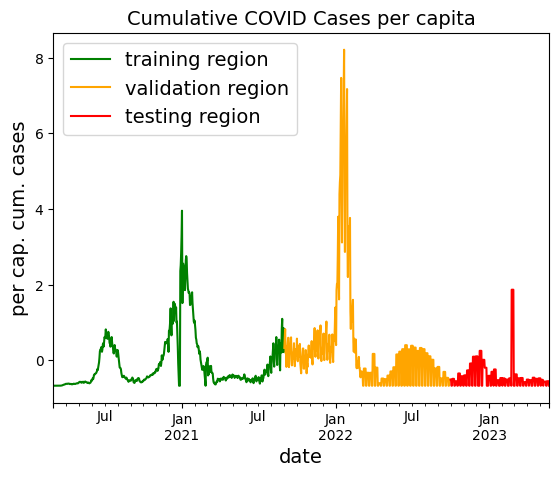

In [144]:
plt.close('all'); # makes sure I'm starting fresh
plt.figure();  # instantiate my figure object
plt.title('Cumulative COVID Cases per capita')

ax = c_train.plot.line(color='Green', label="training region");
c_valid.plot.line(color='Orange', label="validation region");
c_test.plot.line(color='Red', label="testing region")
ax.legend(loc='upper left', frameon=True)
plt.ylabel('per cap. cum. cases')
plt.xlabel('date')

# Solution

In [145]:
# Enter your solution here